# Segmental parameters for non-obese
A system of axes has been defined for each segment, with an origin at the segment mass center, while axes have been aligned with approximate body axes: anteroposterior (x), vertical (y), and mediolateral (z). The corresponding result for the position of the mass center for the head and hand is measured at the center and the center of mass for the thigh is measured from the upper cross section of the thigh lower part, The other segments are measured from the upper cross section of each segment. The measurements are taken with positive values indicating anterior (forward), upward, and lateral (sideways) directions.

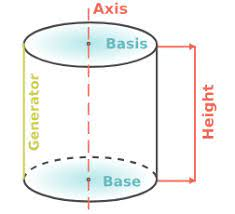

Head+Neck (Ellipsoid)

Upper torso (Frustum of right elliptical cone + Reverted frustum of right elliptical cone)

Middle torso (Reverted frustum of right elliptical cone)

Lower torso (Frustum of right elliptical cone + reverted elliptical cone)

Thigh  (Biased cone + Frustum of cone) 

Shank (Frustum of cone)

Foot (Frustum of cone)

Upper arm (Frustum of cone)

Lower arm (Frustum of cone)

Hand (Sphere)



## 1. Head+Neck (Ellipsoid)
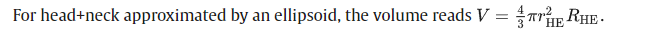
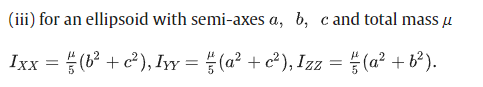

Reference:
Nikolova, Gergana Stefanova, and Yuli Emilov Toshev. "Estimation of male and female body segment parameters of the Bulgarian population using a 16-segmental mathematical model." Journal of biomechanics 40.16 (2007): 3700-3707.


Input parameters: Head_circumference + Head_length + head_mass

In [25]:
# Import Necessary Modules
import glob
import matplotlib.pyplot as plt
from skimage import io
import numpy as np
import math
%matplotlib inline

In [26]:
import numpy as np

head_circumference=57.33
head_length=24.29305825
# Ellipsoid parameters for head and neck
a = head_circumference/(2 * math.pi) # Head circumference
b = head_circumference/(2 * math.pi) # Head circumference
c = head_length/2 # Head length
head_mass = 5.070034541


# Volume of ellipsoid
volume_head = (4/3) * np.pi * a * b * c

# Center of mass of ellipsoid (at the center)
center_of_mass_head_Y =  0
center_of_mass_head_X =  0
center_of_mass_head_Z =  0
# Inertia of ellipsoid

Ixx_head = (1/5) * head_mass * (a**2 + c**2)
Iyy_head = (1/5) * head_mass * (a**2 + b**2)
Izz_head = (1/5) * head_mass * (b**2 + c**2)


print(f"Head and Neck -  Center of Mass(X): {center_of_mass_head_X}, Center of Mass(Y): {center_of_mass_head_Y}, Center of Mass(Z): {center_of_mass_head_Z},(Ixx: {Ixx_head}, Iyy: {Iyy_head}, Izz: {Izz_head})")



Head and Neck -  Center of Mass(X): 0, Center of Mass(Y): 0, Center of Mass(Z): 0,(Ixx: 234.02466755212734, Iyy: 168.8398883349738, Izz: 234.02466755212734)


## 2. Upper Torso Upper torso (Frustum of right elliptical cone+ Reverted Frustum of right elliptical cone)
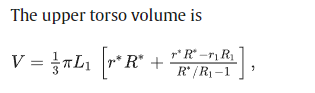
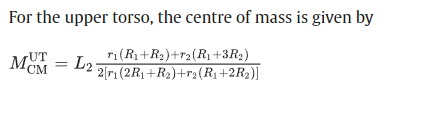
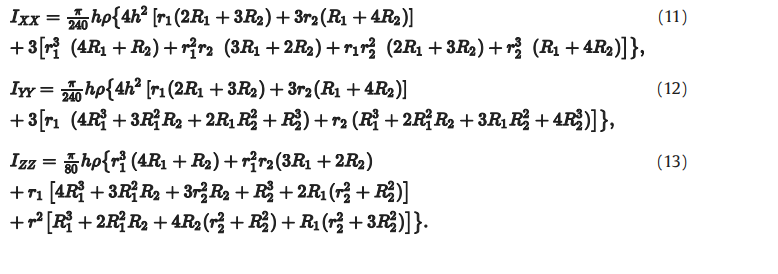


Reference:
Nikolova, Gergana Stefanova, and Yuli Emilov Toshev. "Estimation of male and female body segment parameters of the Bulgarian population using a 16-segmental mathematical model." Journal of biomechanics 40.16 (2007): 3700-3707.

Input parameters: Neckbase_circumference, Shoulder_breadth, Chest_depth, Chest_breadth, upper_torso_mass, upper_torso (length), middle_torso (length), shoulderwaistlen (length)


In [27]:
import numpy as np

def calculate_axes (circumference, diameter):
        """Calculate the semi-major and semi-minor axes from circumference and one axis diameter."""
        semi_major_axis = diameter / 2
        semi_minor_axis = (circumference / (2 * math.pi))**2 - semi_major_axis**2
        semi_minor_axis = math.sqrt(semi_minor_axis) if semi_minor_axis > 0 else semi_major_axis
        return semi_major_axis, semi_minor_axis


def calculate_center_of_mass(h, r1, R1, r2, R2):
    # Calculate the center of mass using the given formula
    center_of_mass = (h * (r1 * (R1 + R2) + r2 * (R1 + 3 * R2))) / (2 * (r1 * (2 * R1 + R2) + r2 * (R1 + 2 * R2)))
    return center_of_mass



def frustum_inertia(r1, R1, r2, R2, density, h):
    """
    Calculate the moments of inertia for a frustum of a right elliptical cone.
    
    Parameters:
    r1 (float): Semi-minor axis of the upper base ellipse
    R1 (float): Semi-major axis of the upper base ellipse
    r2 (float): Semi-minor axis of the lower base ellipse
    R2 (float): Semi-major axis of the lower base ellipse
    density (float): Density of the material
    h (float): Height of the frustum
    
    Returns:
    tuple: (Ixx, Iyy, Izz) moments of inertia for the frustum
    """
    Izz = (np.pi / 240) * density * h * (4*h**2 * (r1*(2*R1 + 3*R2) + 3*r2*(R1 + 4*R2)) + 
                                       3 * (r1**3 * (4*R1 + R2) + r1**2 * r2 * (3*R1 + 2*R2) + 
                                            r1 * r2**2 * (2*R1 + 3*R2) + r2**3 * (R1 + 4*R2)))

    Ixx= (np.pi / 240) * density * h * (
            4*h**2 * (r1*(2*R1 + 3*R2) + 3*r2*(R1 + 4*R2)) + 
            3 * (r1 * (4*R1**3 + 3*R1**2*R2 + 2*R1*R2**2 + R2**3) + 
                 r2 * (R1**3 + 2*R1**2*R2 + 3*R1*R2**2 + 4*R2**3)))
        

    Iyy = (np.pi / 80) * density * h * (
            r1**3 * (4*R1 + R2) + r1**2 * r2 * (3*R1 + 2*R2) + 
            r1 * (4*R1**3 + 3*R1**2*R2 + 3*r2**2*R2 + R2**3 + 2*R1*(r2**2 + R2**2)) + 
            r2 * (R1**3 + 2*R1**2*R2 + 4*R2*(r2**2 + R2**2) + R1*(r2**2 + 3*R2**2)))

    
    return Ixx, Iyy, Izz


## upper part volume (neck~shoulder)

In [28]:
# Parameters for upper torso (upper part)
Neckbase_circumference= 42.56051158
Shoulder_breadth= 41.58
Chest_depth = 23.94
upper_torso= 23.1068407
middle_torso= 23.62299232
shoulderwaistlen= 38.41019798

R1 = Neckbase_circumference/(2 * math.pi) # Neck radius
r1 = Neckbase_circumference/(2 * math.pi) # Neck radius
#R2, r2 = calculate_axes(Shoulder_circumference, Shoulder_breadth) 
R2, r2 = Shoulder_breadth/2, Chest_depth/2
# R1= Shoulder radius semi_major_axis  
# r1= Shoulder radius semi_minor_axis 
necK_shoulder = upper_torso+middle_torso-shoulderwaistlen # height
h1 = necK_shoulder # height

# Volume of elliptical frustum
volume_uppertorso_upper = (1/3) * np.pi * h1 * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))
print(volume_uppertorso_upper)
print(h1)

3498.826375088641
8.319635040000001


## lower part volume (shoulder~chest)

In [29]:

# Parameters for upper torso (lower part)

Shoulder_breadth= 41.58
Chest_depth = 23.94
R1, r1 = Shoulder_breadth/2, Chest_depth/2
#R1, r1 = calculate_axes(Shoulder_circumference, Shoulder_breadth) 
# R1= Shoulder radius semi_major_axis  
# r1= Shoulder radius semi_minor_axis 

Chest_circumference = 101.8232079
Chest_breadth= 28.50779903
Chest_depth = 23.94
#R2, r2 = calculate_axes(Chest_circumference, Chest_breadth) 
 # R2=Chest radius semi_major_axis  
 # r2=Chest radius semi_minor_axis  
R2, r2 = Chest_breadth/2, Chest_depth/2

upper_torso= 23.1068407
middle_torso=23.62299232 #length
shoulderwaistlen= 38.41019798 #length

h2 =  shoulderwaistlen-middle_torso # height

# Volume of elliptical frustum
volume_uppertorso_lower = (1/3) * np.pi * h2 * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))
print(volume_uppertorso_lower)
print(h2)


9686.455332671168
14.787205659999998


Total volume (volume1+volume2)
with Density

In [30]:
volume_uppertorso= volume_uppertorso_upper+volume_uppertorso_lower
uppertorso_mass = 15.6765
#density=0.00087, from Pearsall et al. (1996)
m1=  uppertorso_mass* (volume_uppertorso_upper/volume_uppertorso)
m2=  uppertorso_mass* (volume_uppertorso_lower/volume_uppertorso)
density= uppertorso_mass/volume_uppertorso
print(density)
print(m1)
print(m2)

0.0011889393300390434
4.159892286320823
11.516607713679178


##  Upper Torso Inertia  (upper part)

In [31]:


R1 = Neckbase_circumference/(2 * math.pi) # Neck radius
r1 = Neckbase_circumference/(2 * math.pi) # Neck radius
R2, r2 = Shoulder_breadth/2, Chest_depth/2 
#R2, r2 = calculate_axes(Shoulder_circumference, Shoulder_breadth) 
# R2= Shoulder radius semi_major_axis  
# r2= Shoulder radius semi_minor_axis 
h1 = necK_shoulder # height
print(h1)
#density=0.00087#, from Pearsall et al. (1996)
# Center of mass of upper torso based on formula (3)

# Volume of elliptical frustum
volume_uppertorso_upper = (1/3) * np.pi * h1 * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))

center_of_mass_uppertorso_upper = calculate_center_of_mass(h1, r1, R1, r2, R2)
print(center_of_mass_uppertorso_upper) 
print(density)
Ixx_uppertorso_upper , Iyy_uppertorso_upper , Izz_uppertorso_upper  = frustum_inertia(r1, R1, r2, R2, density, h1)
print(f"Upper Torso_upper -  volume: {volume_uppertorso_upper}, Center of Mass: {center_of_mass_uppertorso_upper}, Inertia: (Ixx: {Ixx_uppertorso_upper}, Iyy: {Iyy_uppertorso_upper}, Izz: {Izz_uppertorso_upper})")



8.319635040000001
5.20042084598885
0.0011889393300390434
Upper Torso_upper -  volume: 3498.826375088641, Center of Mass: 5.20042084598885, Inertia: (Ixx: 402.33955530306196, Iyy: 375.6530046972183, Izz: 241.73010883831387)


##  Upper Torso Inertia (lower part)

In [32]:
# Parameters for upper torso (lower part)

Shoulder_breadth= 41.58
Chest_depth = 23.94
R1, r1 = Shoulder_breadth/2, Chest_depth/2 
#R1, r1= calculate_axes(Shoulder_circumference, Shoulder_breadth) 
# R1= Shoulder radius semi_major_axis  
# r1= Shoulder radius semi_minor_axis 

Chest_circumference = 101.8232079
Chest_breadth= 28.50779903
Chest_depth = 23.94
R2, r2 = Chest_breadth/2, Chest_depth/2 
 # R2=Chest radius semi_major_axis  
 # r2=Chest radius semi_minor_axis  

# Parameters for upper torso (lower part)
upper_torso= 23.1068407
middle_torso= 23.62299232
shoulderwaistlen= 38.41019798
h2 =  shoulderwaistlen-middle_torso # height


#density=0.000872, from Pearsall et al. (1996)
print(density)
# Center of mass of upper torso based on formula (3)

center_of_mass_uppertorso_lower =calculate_center_of_mass(h2, r1, R1, r2, R2)
print(center_of_mass_uppertorso_lower)
volume_uppertorso_lower = (1/3) * np.pi * h2 * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))
# Inertia calculations 
Ixx_uppertorso_lower , Iyy_uppertorso_lower , Izz_uppertorso_lower  = frustum_inertia(r1, R1, r2, R2, density, h2)
print(f"Upper Torso2 - Volume: {volume_uppertorso_lower},  Center of Mass: {center_of_mass_uppertorso_lower}, Inertia: (Ixx: {Ixx_uppertorso_lower}, Iyy: {Iyy_uppertorso_lower}, Izz: {Izz_uppertorso_lower})")



0.0011889393300390434
6.93393812647221
Upper Torso2 - Volume: 9686.455332671168,  Center of Mass: 6.93393812647221, Inertia: (Ixx: 1685.6956541189313, Iyy: 1335.0395802260605, Izz: 1180.565248555999)


##  Combined Inertia Properties (neck base~chest): The parallel axis theorem

In [33]:
# Combined Inertia Properties (neck base~chest)
com1= center_of_mass_uppertorso_upper
com2= h1+center_of_mass_uppertorso_lower
com = (volume_uppertorso_upper* com1 + volume_uppertorso_lower* com2)/volume_uppertorso # use the principle of weighted averages, considering the volume and center of mass of each part
center_of_mass_uppertorso_X=0
center_of_mass_uppertorso_Y=com
center_of_mass_uppertorso_Z=0
d1 = abs(com - com1)
d2 = abs(com - com2)
print(d1)
print(d2)
print(m1)
print(m2)
# incorporate the principles of the parallel axis theorem to adjust the moments of inertia when the center of mass is shifted.
Izz_uppertorso_upper += (m1 * d1**2)
print(Ixx_uppertorso_upper)
Ixx_uppertorso_upper += (m1 * d1**2)
print(Iyy_uppertorso_upper)
Izz_uppertorso_lower += (m2 * d2**2)
print(Ixx_uppertorso_lower )
Ixx_uppertorso_lower += (m2 * d2**2)
print(Iyy_uppertorso_lower )
Ixx_uppertorso= Ixx_uppertorso_upper+Ixx_uppertorso_lower
Iyy_uppertorso= Iyy_uppertorso_upper+Iyy_uppertorso_lower
Izz_uppertorso= Izz_uppertorso_upper+Izz_uppertorso_lower

print(f"Upper Torso - Center of Mass(X): {center_of_mass_uppertorso_X:.2f}, Center of Mass(Y): -{center_of_mass_uppertorso_Y:.2f}, Center of Mass(Z): {center_of_mass_uppertorso_Z:.2f}, Inertia: (Ixx: {Ixx_uppertorso:.2f}, Iyy: {Iyy_uppertorso:.2f}, Izz: {Izz_uppertorso:.2f})")



7.385463053670808
2.6676892668125536
4.159892286320823
11.516607713679178
402.33955530306196
375.6530046972183
1685.6956541189313
1335.0395802260605
Upper Torso - Center of Mass(X): 0.00, Center of Mass(Y): -12.59, Center of Mass(Z): 0.00, Inertia: (Ixx: 2396.90, Iyy: 1710.69, Izz: 1731.16)


## 3. Middle Torso (Reverted Frustum of right elliptical cone) using fomula from upper trunk
Input parameters: Chest_depth, Chest_breadth, Waist_circumference, Waist_depth, Waist_breadth, middle_torso_mass, middle_torso (length)

In [34]:
import numpy as np

# Parameters for middle torso
Chest_circumference = 115.8232079
Chest_breadth = 28.50779903
Chest_depth = 23.94
#R1, r1 = calculate_axes(Chest_circumference, Chest_breadth) 
 # R1=Chest radius semi_major_axis  
 # r1=Chest radius semi_minor_axi


Waist_circumference=87.80767873
Waist_breadth =30.96304633
Waist_depth = 21.82
#R2, r2 = calculate_axes(Waist_circumference, Waist_breadth)
r1=Chest_depth/2
R1=Chest_breadth/2
r2=Waist_depth/2
R2=Waist_breadth/2


# R2=  Waist radius semi_major_axis  
# r2= Waist radius semi_minor_axis 

middle_torso=23.62299232

middletorso_mass= 10.83378109
#middletorso_mass = 9
h =  middle_torso # height
mass= middletorso_mass # mass

# Volume of elliptical frustum
volume_middletorso = (1/3) * np.pi * h * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))

density=mass/volume_middletorso
# density=0.00102, from Pearsall et al. (1996)
print(density)

# Center of mass of middle torso (3)
center_of_mass_middletorso_X = 0
center_of_mass_middletorso_Y = calculate_center_of_mass(h, r1, R1, r2, R2)
center_of_mass_middletorso_Z = 0

# Inertia calculations based on formulas
Ixx_middletorso , Iyy_middletorso, Izz_middletorso   = frustum_inertia(r1, R1, r2, R2, density, h)

print(f"Middle Torso - Center of Mass(X): {center_of_mass_middletorso_X:.2f}, Center of Mass(Y): -{center_of_mass_middletorso_Y:.2f}, Center of Mass(Z): {center_of_mass_middletorso_Z:.2f}, Inertia: (Ixx: {Ixx_middletorso:.2f}, Iyy: {Iyy_middletorso:.2f}, Izz: {Izz_middletorso:.2f})")


0.0008599207666559774
Middle Torso - Center of Mass(X): 0.00, Center of Mass(Y): -11.79, Center of Mass(Z): 0.00, Inertia: (Ixx: 2612.21, Iyy: 954.95, Izz: 2367.71)


## 4. Lower  Torso  using fomula from upper trunk
Input parameters: Waist_depth, Waist_breadth, Hip_breadth, buttock_depth, lower_torso_mass, crotch_height, thigh (length), shank (length), ankle_height (length) 

## ( Frustum of right elliptical cone + elliptical cone)


Lower Torso1_Inertia

In [35]:
# Parameters for lower torso

Waist_circumference=87.80767873  #cm
Waist_breadth=30.96304633  #cm
Waist_depth = 21.82  #cm
thigh = 41.89445507 #cm
shank = 42.89212065 #cm
ankle_height = 7.434086377  #cm
#R1, r1 = calculate_axes(Waist_circumference, Waist_breadth)
# R1=  Waist radius semi_major_axis  
# r1= Waist radius semi_minor_axis 

Buttock_circumference = 98.72524681
Hip_breadth= 33.75483608
buttock_depth= 23.15
#R2, r2 = calculate_axes(Buttock_circumference, Hip_breadth) 
 # R2=Hip radius semi_major_axis  
 # r2=Hip radius semi_minor_axi

r1=Waist_depth/2
R1=Waist_breadth/2
r2=buttock_depth/2
R2 =Hip_breadth/2

lower_torso=16.75644663
lowertorso_mass= 11.31499083
h =  lower_torso # height cm
mass= lowertorso_mass # mass kg
crotch_height= 87.32 
crotch=(ankle_height+shank+thigh)-crotch_height # length for hip ~ crotch

h1 = crotch
# Volume of elliptical frustum
volume_lowertorso_upper = (1/3) * np.pi * h * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))
volume_lowertorso_lower = (np.pi * R2 * r2 * h1) / 3
volume_lowertorso= volume_lowertorso_upper+volume_lowertorso_lower


m1=  lowertorso_mass* (volume_lowertorso_upper/volume_lowertorso)
m2=  lowertorso_mass * (volume_lowertorso_lower/volume_lowertorso)
density= lowertorso_mass/volume_lowertorso
#density=0.00107, from Pearsall et al. (1996)
# Center of mass of lower torso based on formula (3)

center_of_mass_lowertorso_upper = calculate_center_of_mass(h, r1, R1, r2, R2)


Ixx_lowertorso_upper, Iyy_lowertorso_upper, Izz_lowertorso_upper  = frustum_inertia(r1, R1, r2, R2, density, h)

print(f"Lower Torso_upper -  Volume: {volume_lowertorso_upper}, Center of Mass: {center_of_mass_lowertorso_upper}, Inertia: (Ixx: {Ixx_lowertorso_upper}, Iyy: {Iyy_lowertorso_upper}, Izz: {Izz_lowertorso_upper})")

Lower Torso_upper -  Volume: 9579.224047321766, Center of Mass: 8.581205894283297, Inertia: (Ixx: 1665.7954666644746, Iyy: 996.4063717134204, Izz: 1317.8490477005382)


Lower Torso2_Inertia

In [36]:
def elliptical_cone_inertia(R2, r2, h1, m):
    Izz = (3 * m / 20) * (4 * r2**2 + h**2)
    Ixx = (3 * m / 20) * (4 * R2**2 + h**2)
    Iyy = (3 * m / 10) * (r2**2 + R2**2)
   
    return Ixx, Iyy, Izz


Waist_circumference=87.80767873  #cm
Waist_breadth=30.96304633  #cm
r1=Waist_depth/2
R1=Waist_breadth/2
lower_torso=16.75644663
Hip_breadth= 33.75483608
buttock_depth= 23.15
r2=buttock_depth/2
R2=Hip_breadth/2

lowertorso_mass= 11.31499083
h =  lower_torso # height cm
mass= lowertorso_mass # mass kg
crotch_height= 87.32 
crotch=(ankle_height+shank+thigh)-crotch_height # length for hip ~ crotch
h1=crotch
print(h1)
# Volume of elliptical frustum
volume_lowertorso_upper = (1/3) * np.pi * h * (R1 * r1 + R2 * r2 + np.sqrt(R1 * r1 * R2 * r2))
volume_lowertorso_lower = (np.pi * R2 * r2 * h1) / 3
volume_lowertorso= volume_lowertorso_upper+volume_lowertorso_lower


m1=  lowertorso_mass* (volume_lowertorso_upper/volume_lowertorso)
m2=  lowertorso_mass * (volume_lowertorso_lower/volume_lowertorso)
density= lowertorso_mass/volume_lowertorso
#density=0.00107, from Pearsall et al. (1996)
L2=h1
center_of_mass_lowertorso_lower = (L2)/4

Ixx_lowertorso_lower, Iyy_lowertorso_lower, Izz_lowertorso_lower = elliptical_cone_inertia(R2, r2, h1, m2)

print(f"Lower Torso_lower -  Volume: {volume_lowertorso_lower}, Center of Mass: {center_of_mass_lowertorso_lower}, Inertia: (Ixx: {Ixx_lowertorso_lower}, Iyy: {Iyy_lowertorso_lower}, Izz: {Izz_lowertorso_lower})")


4.9006620970000085
Lower Torso_lower -  Volume: 1002.5600250315036, Center of Mass: 1.2251655242500021, Inertia: (Ixx: 228.36866466323738, Iyy: 134.69842495823625, Izz: 131.3288204152363)


In [37]:
# Combined Inertia Properties (waist~crotch)
com1= center_of_mass_lowertorso_upper
com2= lower_torso+center_of_mass_lowertorso_lower
center_of_mass_lowertorso_Y= (volume_lowertorso_upper* com1 + volume_lowertorso_lower * com2)/volume_lowertorso# use the principle of weighted averages, considering the volume and center of mass of each part
center_of_mass_lowertorso_X =0
center_of_mass_lowertorso_Z =0
d1 = abs(com - com1)
d2 = abs(com - com2)
# incorporate the principles of the parallel axis theorem to adjust the moments of inertia when the center of mass is shifted.
Izz_lowertorso_upper += (m1 * d1**2)
Ixx_lowertorso_upper += (m1 * d1**2)
Izz_lowertorso_lower += (m2 * d2**2)
Ixx_lowertorso_lower += (m2 * d2**2)
Ixx_lowertorso= Ixx_lowertorso_upper+Ixx_lowertorso_lower
Iyy_lowertorso= Iyy_lowertorso_upper+Iyy_lowertorso_lower
Izz_lowertorso= Izz_lowertorso_upper+Izz_lowertorso_lower

print(f"Lower Torso -  Center of Mass(X): {center_of_mass_lowertorso_X:.2f}, Center of Mass(Y): -{center_of_mass_lowertorso_Y:.2f}, Center of Mass(Z): {center_of_mass_lowertorso_Z:.2f}, Inertia: (Ixx: {Ixx_lowertorso:.2f}, Iyy: {Iyy_lowertorso:.2f}, Izz: {Izz_lowertorso:.2f})")

Lower Torso -  Center of Mass(X): 0.00, Center of Mass(Y): -9.47, Center of Mass(Z): 0.00, Inertia: (Ixx: 2089.65, Iyy: 1131.10, Izz: 1644.66)


## Frustum of cone and biased cone formula for thigh



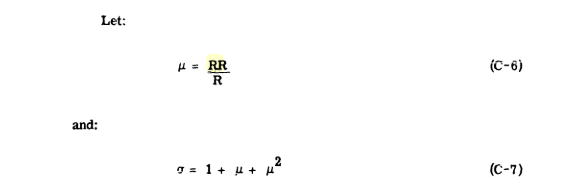
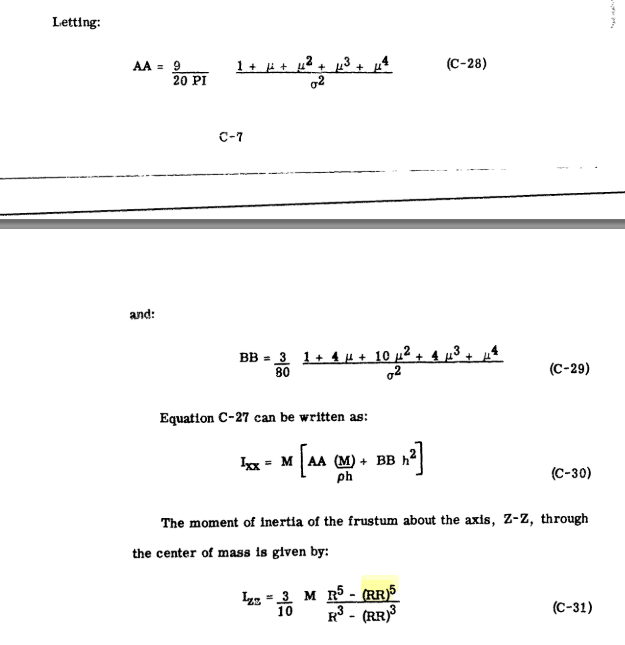
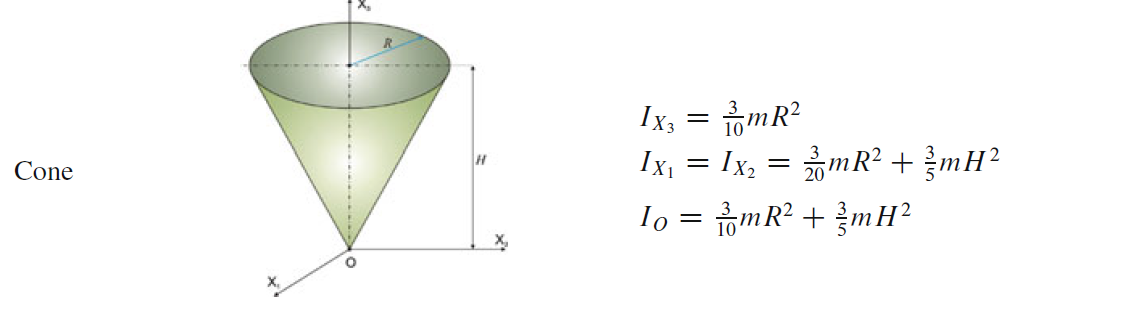

Reference:

Hanavan Jr, Ernest P. "A mathematical model of the human body." (1965). 

Awrejcewicz, Jan, and Jan Awrejcewicz. "Geometry of Masses." Classical Mechanics: Kinematics and Statics (2012): 131-185.

In [38]:
def calculate_Ixx_Izz_frustum_of_right_circular_cone(M, R1, R2, density, h):
    

    # Given values
    mu = R1 / R2
    sigma = 1 + mu + mu**2

    # Calculate AA
    AA = (9 / (20 * np.pi)) * (1 + mu + mu**2 + mu**3 + mu**4) / sigma**2

    # Calculate BB
    BB = (3 / 80) * (1 + 4 * mu + 10 * mu**2 + 4 * mu**3 + mu**4) / sigma**2

    # Calculate Ixx
    Izz = M * (AA * M / (density * h) + BB * h**2)
    Ixx=  Izz
    # Calculate Izz
    Iyy = 3/10*(M * (R2**5 - R1**5)) /(R2**3 - R1**3)


    return Ixx, Iyy, Izz

In [39]:



def cone_inertia(R, h, m):
    # For a circular cone
    Izz = (3 * m / 20) * (4 * R**2 + h**2)
    Ixx = Izz  # Same as Ixx for a circular base
    Iyy = (3 * m / 5) * R**2
    return Ixx, Iyy, Izz


## 5.Thigh

Input parameters: thigh_circumference, lowerthigh_circumference, thigh_mass, thigh (length), crotch_height


 ##  Frustum and biased cone for thigh

In [40]:


# Frustum parameters for thigh
thigh = 41.89445507 #cm
thigh_circumference = 59.4984303 #cm
thigh_mass= 9.30942572 #kg
calf_circumference = 38.11171942 #cm
crotch_height= 87.32 
crotch=(ankle_height+shank+thigh)-crotch_height # length for hip ~ crotch
h1=crotch # height
print(h1)
# Frustum parameters for thigh
r1 =thigh_circumference/(2 * np.pi)   # radius at one end
r2 =calf_circumference/(2 * np.pi)  # radius at other end

h2 = thigh-crotch   # height
mass = thigh_mass

# Volume of of biased cone
volume_upperthigh =  (np.pi * (r1)**2 * h1) / 3
# Volume of frustum 
volume_lowerthigh = (1/3) * np.pi * h2 * (r1**2 + r2**2 + r1*r2)


volume_thigh= volume_upperthigh+volume_lowerthigh


m1=  thigh_mass* (volume_upperthigh/volume_thigh)
m2=  thigh_mass * (volume_lowerthigh/volume_thigh)
density= thigh_mass/volume_thigh
print(m1)
print(m2)
# Center of mass of biased cone
center_of_mass_upper = h1*(3/4)

# Center of mass of frustum
center_of_mass_lower = h2 * (r2**2 + 2 * r1 * r2) / (3 * (r1**2 + r2**2 + r1 * r2))


# Inertia of cone 

Ixx_upperthigh, Iyy_upperthigh, Izz_upperthigh = cone_inertia(r1, h1, m1)

# Inertia of frustum
Ixx_lowerthigh, Iyy_lowerthigh, Izz_lowerthigh = calculate_Ixx_Izz_frustum_of_right_circular_cone(m2, r1, r2, density, h2)


print(f"Thigh_upper -  Volume: {volume_upperthigh}, Center of Mass: {center_of_mass_upper}, Inertia: (Ixx: {Ixx_upperthigh}, Iyy: {Iyy_upperthigh}, Izz: {Izz_upperthigh}")
print(f"Thigh_upper -  Volume: {volume_lowerthigh}, Center of Mass: {center_of_mass_lower}, Inertia: (Ixx: {Ixx_lowerthigh}, Iyy: {Iyy_lowerthigh}, Izz: {Izz_lowerthigh}")


# Combined Inertia Properties (crotch~knee)
com1_y= center_of_mass_upper
com1_z = (r1)*(0.25)+r1
print(com1_z)
com2_y=  crotch+center_of_mass_lower
com2_z = r1
print(com2_z)
com_y = (volume_upperthigh* com1_y + volume_lowerthigh* com2_y)/volume_thigh # use the principle of weighted averages, considering the volume and center of mass of each part
com_z = (volume_upperthigh* com1_z + volume_lowerthigh* com2_z)/volume_thigh # use the principle of weighted averages, considering the volume and center of mass of each part
print(com_z)
center_of_mass_thigh_Y =com_y
center_of_mass_thigh_Y = com_y-h1 #subtract crotch height since the mass of center for thigh is measured from the upper cross section of the thigh lower part.
center_of_mass_thigh_X =0
center_of_mass_thigh_Z = abs(com_z-r1)

d1_y = abs(com_y - com1_y)
d2_y = abs(com_y - com2_y)
d1_z = abs(com_z - com1_z)
d2_z = abs(com_z - com2_z)
# incorporate the principles of the parallel axis theorem to adjust the moments of inertia when the center of mass is shifted.
Izz_upperthigh += (m1 * d1_y**2)
Ixx_upperthigh += (m1 * d1_y**2+ m1 * d1_z**2)
Iyy_upperthigh += (m1 * d1_z**2)
Izz_lowerthigh += (m2 * d2_y**2)
Ixx_lowerthigh += (m2 * d2_y**2+ m2 * d2_z**2)
Iyy_upperthigh += (m2 * d2_z**2)
Ixx_thigh= Ixx_upperthigh+Ixx_lowerthigh
Iyy_thigh= Iyy_upperthigh+Iyy_lowerthigh
Izz_thigh= Izz_upperthigh+Izz_lowerthigh



print(f"Thigh -  Center of Mass(X): {center_of_mass_thigh_X:.2f}, Center of Mass(Y): -{center_of_mass_thigh_Y:.2f}, Center of Mass(Z): {center_of_mass_thigh_Z:.2f}, Inertia: (Ixx: {Ixx_thigh:.2f}, Iyy: {Iyy_thigh:.2f}, Izz: {Izz_thigh:.2f})")

4.9006620970000085
0.5648459674848596
8.74457975251514
Thigh_upper -  Volume: 460.1873290131371, Center of Mass: 3.6754965727500064, Inertia: (Ixx: 32.42497288506108, Iyy: 30.39013034127623, Izz: 32.42497288506108
Thigh_upper -  Volume: 7124.322437090192, Center of Mass: 10.169983053643492, Inertia: (Ixx: 1090.3512109565079, Iyy: 284.6968785465682, Izz: 1090.3512109565079
11.836836610567003
9.469469288453602
9.613108426427324
Thigh -  Center of Mass(X): 0.00, Center of Mass(Y): -9.48, Center of Mass(Z): 0.14, Inertia: (Ixx: 1194.64, Iyy: 318.06, Izz: 1191.67)


## Frustum of cone formula for  shank, and foot, upper arm, lower arm, using thigh's formula



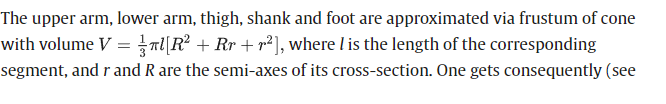
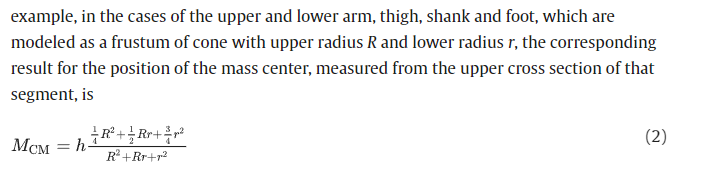

Reference:

Nikolova, Gergana Stefanova, and Yuli Emilov Toshev. "Estimation of male and female body segment parameters of the Bulgarian population using a 16-segmental mathematical model." Journal of biomechanics 40.16 (2007): 3700-3707.

Hanavan Jr, Ernest P. "A mathematical model of the human body." (1965). 



## 6. Shank
Input parameters : calf_circumference, ankle_circumference, shank_mass, shank (length) 

In [41]:


# Frustum parameters for shank
shank = 42.89212065 #cm
calf_circumference = 38.11171942 #cm
ankle_circumference = 22.58078373 #cm
shank_mass=3.1445993 #kg

# Frustum parameters for upper arm
r1 =calf_circumference/(2 * math.pi)   # radius at one end
r2 =ankle_circumference/(2 * math.pi)  # radius at other end
h = shank   # height
mass = shank_mass


# Volume of frustum of frustum
volume_shank = (1/3) * np.pi * h * (r1**2 + r2**2 + r1*r2)
density = mass/volume_shank

# Center of mass
center_of_mass_shank_Y = h * (r2**2 + 2 * r1 * r2) / (3 * (r1**2 + r2**2 + r1 * r2)) 
center_of_mass_shank_X = 0
center_of_mass_shank_Z = 0
# Inertia of frustum
Ixx_shank, Iyy_shank, Izz_shank = calculate_Ixx_Izz_frustum_of_right_circular_cone(mass, r1, r2, density, h)




print(f"Shank -  Center of Mass(X): {center_of_mass_shank_X:.2f}, Center of Mass(Y): -{center_of_mass_shank_Y:.2f}, Center of Mass(Z): {center_of_mass_shank_Z:.2f}, Inertia: (Ixx: {Ixx_shank:.2f}, Iyy: {Iyy_shank:.2f}, Izz: {Izz_shank:.2f})")


Shank -  Center of Mass(X): 0.00, Center of Mass(Y): -11.30, Center of Mass(Z): 0.00, Inertia: (Ixx: 470.34, Iyy: 40.62, Izz: 470.34)


## 7. foot

Input parameters (foot) : balloffoot_circumference, shnak_mass, ankle_height, foot (length) 

In [42]:


# Frustum parameters for foot
foot = 27.59313917 #cm
ankle_height = 7.434086377 #cm
balloffoot_circumference = 25.12666045#cm
foot_mass= 0.929429937 #kg

# Frustum parameters for upper arm
r1 =ankle_height/2    # radius at one end
r2 =balloffoot_circumference/(2 *np.pi)  # radius at other end
h = foot   # height
mass = foot_mass

# Volume of frustum
volume_foot = (1/3) * np.pi * h * (r1**2 + r2**2 + r1*r2)
density = mass/volume_foot

# Center of mass of frustum
center_of_mass_foot_X = (h * (r2**2 + 2 * r1 * r2) / (3 * (r1**2 + r2**2 + r1 * r2))) 
center_of_mass_foot_Y = r1
center_of_mass_foot_Z = 0

# Inertia of frustum
Ixx_foot, Iyy_foot, Izz_foot = calculate_Ixx_Izz_frustum_of_right_circular_cone(mass, r1, r2, density, h)

print(f"Foot - Center of Mass(X): {center_of_mass_foot_X:.2f}, Center of Mass(Y): -{center_of_mass_foot_Y:.2f}, Center of Mass(Z): {center_of_mass_foot_Z:.2f}, Inertia: (Ixx: {Iyy_foot:.2f}, Iyy: {Ixx_foot:.2f}, Izz: {Izz_foot:.2f})")



Foot - Center of Mass(X): 9.41, Center of Mass(Y): -3.72, Center of Mass(Z): 0.00, Inertia: (Ixx: 6.93, Iyy: 62.35, Izz: 62.35)


## 8. Upper arm 

Input parameters: biceps_circumference, forearm_circumference, upperarm_mass, upperarm (length) 

In [43]:

# Frustum parameters for uppperarm
upperarm= 34.28636885 #cm
biceps_circumference = 34.2 #cm
forearm_circumference = 30.35756932 #cm
upperarm_mass=2.878196874 #kg


# Frustum parameters for upper arm
r1 =biceps_circumference/( 2*np.pi)   # radius at one end
r2 =forearm_circumference/( 2*np.pi)  # radius at other end
h = upperarm   # height
mass = upperarm_mass

# Volume of frustum
volume_upperarm = (1/3) * np.pi * h * (r1**2 + r2**2 + r1*r2)
density = mass/volume_upperarm

# Center of mass of frustum
center_of_mass_upperarm_Y = h * (r2**2 + 2 * r1 * r2) / (3 * (r1**2 + r2**2 + r1 * r2)) 
center_of_mass_upperarm_X = 0
center_of_mass_upperarm_Z =0 
# Inertia of frustum
Ixx_upperarm, Iyy_upperarm, Izz_upperarm = calculate_Ixx_Izz_frustum_of_right_circular_cone(mass, r1, r2, density, h)


print(f"Upper Arm -  Center of Mass(X): {center_of_mass_upperarm_X:.2f}, Center of Mass(Y): -{center_of_mass_upperarm_Y:.2f}, Center of Mass(Z): {center_of_mass_upperarm_Z:.2f},  Inertia: (Ixx: {Ixx_upperarm:.2f}, Iyy: {Iyy_upperarm:.2f}, Izz: {Izz_upperarm:.2f})")


Upper Arm -  Center of Mass(X): 0.00, Center of Mass(Y): -10.95, Center of Mass(Z): 0.00,  Inertia: (Ixx: 300.00, Iyy: 38.20, Izz: 300.00)


## 9. Forearm

Input parameters : forearm_circumference, wrist_circumference, forearm_mass, forearm (length) 

In [44]:

# Frustum parameters for forearm
forearm = 29.33639148 #cm
forearm_circumference = 30.35756932 #cm
wrist_circumference = 17.50775304 #cm
forearm_mass=1.633991062 #kg


# Frustum parameters for lower arm
r1 =forearm_circumference/(2 * math.pi)   # radius at one end
r2 =wrist_circumference/(2 * math.pi)  # radius at other end
h = forearm   # height
mass = forearm_mass


# Volume of frustum
volume_forearm = (1/3) * np.pi * h * (r1**2 + r2**2 + r1*r2)
density = mass/volume_forearm

# Center of mass of frustum
center_of_mass_forearm_Y = h * (r2**2 + 2 * r1 * r2) / (3 * (r1**2 + r2**2 + r1 * r2)) 
center_of_mass_forearm_X = 0
center_of_mass_forearm_Z = 0
# Inertia of frustum
Ixx_forearm, Iyy_forearm, Izz_forearm = calculate_Ixx_Izz_frustum_of_right_circular_cone(mass, r1, r2, density, h)


print(f"Lower Arm - Center of Mass(X): {center_of_mass_forearm_X:.2f}, Center of Mass(Y): -{center_of_mass_forearm_Y:.2f}, Center of Mass(Z): {center_of_mass_forearm_Z:.2f}, Inertia: (Ixx: {Ixx_forearm:.2f}, Iyy: {Iyy_forearm:.2f}, Izz: {Izz_forearm:.2f})")


Lower Arm - Center of Mass(X): 0.00, Center of Mass(Y): -7.61, Center of Mass(Z): 0.00, Inertia: (Ixx: 115.28, Iyy: 13.26, Izz: 115.28)


## 10. Hand using sphere
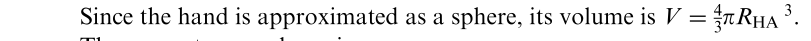
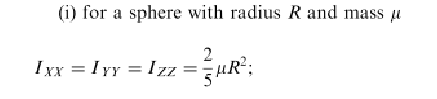

Nikolova, Gergana Stefanova, and Yuli Emilov Toshev. "Estimation of male and female body segment parameters of the Bulgarian population using a 16-segmental mathematical model." Journal of biomechanics 40.16 (2007): 3700-3707.

Input parameters : hand (length), hand_mass

In [46]:

# Frustum parameters for hand
Hand_length=19.64172797

c = Hand_length/4 # Hand length
hand_mass = 0.656703408


# Volume of ellipsoid
volume_hand = (4/3) * np.pi * c**3

# Center of mass of sphere (at the center)
center_of_mass_hand_Y =  0
center_of_mass_hand_X =  0
center_of_mass_hand_Z =  0

# Inertia of sphere f

I_zz_hand=2/5*hand_mass*(c)**2
I_xx_hand=2/5*hand_mass*(c)**2
I_yy_hand=2/5*hand_mass*(c)**2

print(f"Hand - Center of Mass(X): {center_of_mass_hand_X:.2f}, Center of Mass(Y): {center_of_mass_hand_Y:.2f}, Center of Mass(Z): {center_of_mass_hand_Z:.2f}, Inertia (Ixx: {I_xx_hand:.2f}, Iyy: {I_yy_hand:.2f}, Izz: {I_zz_hand:.2f})")


Hand - Center of Mass(X): 0.00, Center of Mass(Y): 0.00, Center of Mass(Z): 0.00, Inertia (Ixx: 6.33, Iyy: 6.33, Izz: 6.33)
